In [2]:
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [3]:
path = "/content/gdrive/MyDrive/Praktikum/Praktikum03"

In [4]:
import pandas as pd
df = pd.read_csv(path + '/data/day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [13]:
df1 = (df[["cnt", "registered", "casual", "weathersit", "weekday", "holiday", "season"]]
    .rename(columns={"cnt": "total_sewa",
                     "registered": "sewa_terdaftar",
                     "casual": "sewa_tdkterdaftar",
                     "weathersit": "cuaca",
                     "weekday": "hari_kerja",
                     "holiday": "hari_libur",
                     "season": "musim"}).copy())
df1.head()

,total_sewa,sewa_terdaftar,sewa_tdkterdaftar,cuaca,hari_kerja,hari_libur,musim
0,985,654,331,2,6,0,1
1,801,670,131,2,0,0,1
2,1349,1229,120,1,1,0,1
3,1562,1454,108,1,2,0,1
4,1600,1518,82,1,3,0,1


In [14]:
corr_matrix = df1.corr()
print(corr_matrix)

                   total_sewa  sewa_terdaftar  sewa_tdkterdaftar     cuaca  \
total_sewa           1.000000        0.945517           0.672804 -0.297391   
sewa_terdaftar       0.945517        1.000000           0.395282 -0.260388   
sewa_tdkterdaftar    0.672804        0.395282           1.000000 -0.247353   
cuaca               -0.297391       -0.260388          -0.247353  1.000000   
hari_kerja           0.067443        0.057367           0.059923  0.031087   
hari_libur          -0.068348       -0.108745           0.054274 -0.034627   
musim                0.406100        0.411623           0.210399  0.019211   

                   hari_kerja  hari_libur     musim  
total_sewa           0.067443   -0.068348  0.406100  
sewa_terdaftar       0.057367   -0.108745  0.411623  
sewa_tdkterdaftar    0.059923    0.054274  0.210399  
cuaca                0.031087   -0.034627  0.019211  
hari_kerja           1.000000   -0.101960 -0.003080  
hari_libur          -0.101960    1.000000 -0.010537

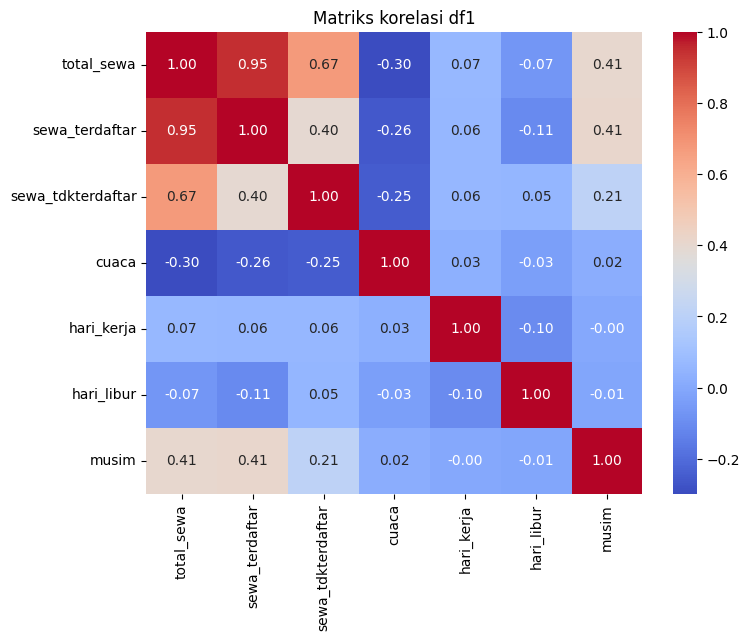

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks korelasi df1')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

# Misalkan target (Y) adalah berat badan, # Variabel dependen
y = df1["total_sewa"]

# Fitur (X) adalah umur dan tinggi, # Variabel independen
X = df1[["sewa_terdaftar","sewa_tdkterdaftar","cuaca","hari_kerja","hari_libur","musim"]]

# Bagi data 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 # random_state supaya hasil konsisten
)

## Cetak Pembagian Data
print("Jumlah data X_train :", len(X_train))
print("Jumlah data X_test :", len(X_test))
print("Jumlah data y_test :", len(y_test))
print("Jumlah data y_train :", len(y_train))

# cek apakah sudah ada constanta pada data training
X_train.head()

Jumlah data X_train : 584
Jumlah data X_test : 147
Jumlah data y_test : 147
Jumlah data y_train : 584


,sewa_terdaftar,sewa_tdkterdaftar,cuaca,hari_kerja,hari_libur,musim
682,3767,327,2,2,0,4
250,1689,153,3,4,0,3
336,2908,706,1,6,0,4
260,2921,1353,1,0,0,3
543,6258,1077,1,3,0,3


In [18]:
import statsmodels.api as sm
X_train_const = sm.add_constant(X_train)
X_train_const.head()

,const,sewa_terdaftar,sewa_tdkterdaftar,cuaca,hari_kerja,hari_libur,musim
682,1.0,3767,327,2,2,0,4
250,1.0,1689,153,3,4,0,3
336,1.0,2908,706,1,6,0,4
260,1.0,2921,1353,1,0,0,3
543,1.0,6258,1077,1,3,0,3


In [20]:
model = sm.OLS(y_train, X_train_const).fit()
print('----------------------------')
print(model.params)
print('----------------------------')
const = model.params['const']
x1_sewa_terdaftar = model.params['sewa_terdaftar']
x2_sewa_tdkterdaftar = model.params['sewa_tdkterdaftar']
x3_cuaca = model.params['cuaca']
x4_hari_kerja = model.params['hari_kerja']
x5_hari_libur = model.params['hari_libur']
x6_musim = model.params['musim']
# print persamaan regresi
print(f"y = {const:.3f} + ({x1_sewa_terdaftar:.3f})*x1 + ({x2_sewa_tdkterdaftar:.3f})*x2 + ({x3_cuaca:.3f})*x3 + ({x4_hari_kerja:.3f})*x4 + ({x5_hari_libur:.3f})*x5 + ({x6_musim:.3f})*x6")

----------------------------
const               -1.136868e-12
sewa_terdaftar       1.000000e+00
sewa_tdkterdaftar    1.000000e+00
cuaca                9.805490e-13
hari_kerja           1.989520e-13
hari_libur           1.136868e-12
musim                6.394885e-14
dtype: float64
----------------------------
y = -0.000 + (1.000)*x1 + (1.000)*x2 + (0.000)*x3 + (0.000)*x4 + (0.000)*x5 + (0.000)*x6


In [21]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             total_sewa   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.375e+31
Date:                Sun, 12 Oct 2025   Prob (F-statistic):               0.00
Time:                        13:27:35   Log-Likelihood:                 14759.
No. Observations:                 584   AIC:                        -2.950e+04
Df Residuals:                     577   BIC:                        -2.947e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -1.137e-12   4.86e-1

In [23]:
import numpy as np
X_test_const = sm.add_constant(X_test)

y_pred_test = model.predict(X_test_const)


hasil = pd.DataFrame({
    "Sewa Terdaftar": X_test["sewa_terdaftar"].to_numpy(),
    "Sewa Tidak Terdaftar": X_test["sewa_tdkterdaftar"].to_numpy(),
    "Cuaca": X_test["cuaca"].to_numpy(),
    "Hari Kerja": X_test["hari_kerja"].to_numpy(),
    "Hari Libur": X_test["hari_libur"].to_numpy(),
    "Musim": X_test["musim"].to_numpy(),

    "Total Sewa Aktual": y_test.to_numpy(),
    "Total Sewa Prediksi": y_pred_test
})


hasil["Selisih error"] = hasil["Total Sewa Prediksi"] - hasil["Total Sewa Aktual"]

denom = hasil["Total Sewa Aktual"].replace(0, np.nan)
hasil["Akurasi (%)"] = (1 - (hasil["Selisih error"].abs() / denom)).clip(lower=0, upper=1) * 100

hasil

,Sewa Terdaftar,Sewa Tidak Terdaftar,Cuaca,Hari Kerja,Hari Libur,Musim,Total Sewa Aktual,Total Sewa Prediksi,Selisih error,Akurasi (%)
703,6055,551,1,2,0,4,6606,6606.0,9.094947e-13,100.0
33,1489,61,1,4,0,1,1550,1550.0,9.094947e-13,100.0
300,3291,456,2,5,0,4,3747,3747.0,3.183231e-12,100.0
456,3694,2347,2,0,0,2,6041,6041.0,3.637979e-12,100.0
633,6693,845,1,2,0,4,7538,7538.0,2.728484e-12,100.0
...,...,...,...,...,...,...,...,...,...,...
70,1408,724,1,6,0,1,2132,2132.0,2.273737e-12,100.0
192,3596,662,1,2,0,3,4258,4258.0,9.094947e-13,100.0
328,1697,1095,1,5,0,4,2792,2792.0,2.273737e-12,100.0
165,4411,769,1,3,0,2,5180,5180.0,2.728484e-12,100.0
